In [74]:
import sys
sys.path.insert(0,'..')
import os 
import pickle 

import oqupy
from oqupy.tti_tempo import TTITempo
import oqupy.operators as op
import numpy as np
import matplotlib.pyplot as plt

# plt.style.use('physrev') # Set full path to if physrev.mplstyle is not in the same in directory as the notebook
# plt.rcParams['figure.dpi'] = "300"

import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize,Bounds



# ----------------- Parameters --------------

# --- Bath ----

omega_cutoff = 5.0*2*np.pi
alpha = 0.03
temperature = 0.0
t_max = 11.0
dt = 1./omega_cutoff/np.sqrt(3)/2 
num_steps = int(t_max/dt)
t_list = np.linspace(0,t_max,num_steps)
dt_half = 1./omega_cutoff/np.sqrt(3)/4 # Accounts for the fact that we use half-time propagators.
num_steps_half = int(t_max/dt_half)
t_list_half = np.linspace(0,t_max,num_steps_half)


name = 'alpha{}tmax{}'.format(alpha,t_max)
name_replaced = name.replace('.','-')
name_path = os.path.abspath('')[0:-9]+'/transmon/'+name_replaced
# name_path = os.path.dirname(__file__)+'/opt/'+name_replaced

opt_file = open(name_path, 'rb')    
dict_run = pickle.load(opt_file)

x0 = dict_run['optimization_result'].x

a = oqupy.operators.destroy(5)




In [75]:
correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1.0,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)
bath = oqupy.Bath((a+np.conjugate(a.T))/2.0, correlations)
parameters=oqupy.TempoParameters(dt=dt,epsrel=1e-8,dkmax=50000)
pt=TTITempo(bath,start_time=0.0,parameters=parameters)

building influence functional: 100%|██████████| 50000/50000 [32:02<00:00, 26.01it/s] 


rank  156


In [77]:
process_tensor_tebd = pt.get_process_tensor()

def discrete_hamiltonian(hx):
        return 2*hx*np.conjugate(a.T)@a + omega_cutoff/10.0/2.0*np.conjugate(a.T)@np.conjugate(a.T)@a@a

system = oqupy.ParameterizedSystem(discrete_hamiltonian)

h_x_0 = np.expand_dims(np.ones(2*num_steps)*omega_cutoff/2,1)
h_x_opt = np.expand_dims(dict_run['optimization_result'].x,1)


# initial_state = np.eye(2)/2.0
# target_state = np.array([[1,0],[0,0]])
# initial_state = np.eye(3)/3.0
initial_state = np.diag([1,0,0,0,0])
target_state = np.diag([1,0,0,0,0])

target_derivative = target_state.T

In [78]:
grad_res_0 = oqupy.state_gradient(
    system=system,
    initial_state=initial_state,
    target_derivative=target_derivative,
    process_tensors=[process_tensor_tebd],
    num_steps=num_steps,
    parameters=h_x_0,
    only_dynamics=True)

dynamics_0 = grad_res_0['dynamics']

# t, p0_0 = dynamics_0.expectations(np.diag([1,0]), real=True)

t, p0_0 = dynamics_0.expectations(np.diag([1,0,0,0,0]), real=True)
t, p1_0 = dynamics_0.expectations(np.diag([0,1,0,0,0]), real=True)
t, p2_0 = dynamics_0.expectations(np.diag([0,0,1,0,0]), real=True)
t, p3_0 = dynamics_0.expectations(np.diag([0,0,0,1,0]), real=True)

grad_res_opt = oqupy.state_gradient(
    system=system,
    initial_state=initial_state,
    target_derivative=target_derivative,
    process_tensors=[process_tensor_tebd],
    num_steps=num_steps,
    parameters=h_x_opt,
    only_dynamics=True)

dynamics_opt = grad_res_opt['dynamics']

# t, p0_opt = dynamics_opt.expectations(np.diag([1,0]), real=True)
t, p0_opt = dynamics_opt.expectations(np.diag([1,0,0,0,0]), real=True)
t, p1_opt = dynamics_opt.expectations(np.diag([0,1,0,0,0]), real=True)
t, p2_opt = dynamics_opt.expectations(np.diag([0,0,1,0,0]), real=True)
t, p3_opt = dynamics_opt.expectations(np.diag([0,0,0,3,0]), real=True)

--> Compute forward propagation:
100.0% 1197 of 1197 [########################################] 00:10:46
Elapsed time: 647.0s
--> Compute forward propagation:
100.0% 1197 of 1197 [########################################] 00:08:20
Elapsed time: 500.6s


In [90]:
t, p4_0 = dynamics_0.expectations(np.diag([0,0,0,0,4]), real=True)

/tmp/ipykernel_26768/4138279423.py:6: RuntimeWarning: divide by zero encountered in log10
  plt.plot(t,np.log10(p1_opt),'k', label = 'TEMPO',linestyle = 'solid')
/tmp/ipykernel_26768/4138279423.py:7: RuntimeWarning: divide by zero encountered in log10
  plt.plot(t,np.log10(p2_opt),'k', label = 'TEMPO',linestyle = 'solid')


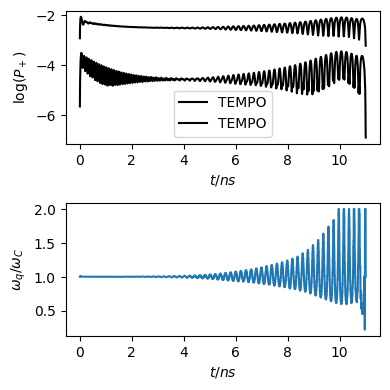

In [60]:


# plt.plot(t_list_half[0:num_steps_half], np.log10((1+np.array(resTDVP))/2), 'k',label='TDVP', linestyle='dotted')
# plt.plot(t_list_half[0:num_steps_half], np.log10((1+np.array(resTDVP))/2), 'k',label='TDVP', linestyle='dashed')
plt.figure(figsize=(4,4))

plt.subplot(211)
plt.plot(t,np.log10(p1_opt),'k', label = 'TEMPO',linestyle = 'solid')
plt.plot(t,np.log10(p2_opt),'k', label = 'TEMPO',linestyle = 'solid')
plt.legend( prop={'size': 6})
plt.xlabel(r'$t/ns$')
plt.ylabel(r'$\log(P_+)$')
plt.legend()

plt.subplot(212)
plt.plot(t_list_half[0:num_steps_half],2*h_x_opt/omega_cutoff)
plt.xlabel(r'$t/ns$')
plt.ylabel(r'$\omega_q/\omega_C$')

plt.tight_layout()


plt.show()

In [91]:
import scipy, math
from scipy import special

N=10000
c = 10*omega_cutoff/N

def omega_k(k):
    return c*np.abs(k)
def g_k(k):
    return np.sqrt(2*alpha*c*omega_k(k))*np.exp(-omega_k(k)/2/omega_cutoff)

wk_vec = np.array([omega_k(k) for k in range(0,N)])
gk_vec = np.array([g_k(k) for k in range(0,N)])

X=0.0
for i in range(0,10):
    fk_vec = -gk_vec/2/(omega_cutoff+3*omega_cutoff/10.0*X+wk_vec)
    X = np.linalg.norm(fk_vec)**2

p0_pol = 1+np.sum([ ((-1)**p)/(math.factorial(p))*X**(p)*special.factorial2(2*(p)-1) for p in range(1,22)])
p1_pol = np.sum([ ((-1)**p)/(math.factorial(p))*X**(p+1)*special.factorial2(2*(1+p)-1) for p in range(0,22)])
p2_pol = np.sum([ ((-1)**p)/(2*math.factorial(p))*X**(p+2)*special.factorial2(2*(2+p)-1) for p in range(0,22)])
p3_pol = np.sum([ ((-1)**p)/(3*2*math.factorial(p))*X**(p+3)*special.factorial2(2*(3+p)-1) for p in range(0,22)])
p4_pol = np.sum([ ((-1)**p)/(4*3*2*math.factorial(p))*X**(p+4)*special.factorial2(2*(4+p)-1) for p in range(0,22)])

In [58]:
p0_pol

0.997137167173381

/tmp/ipykernel_26768/3544113475.py:6: RuntimeWarning: divide by zero encountered in log10
  plt.plot(t,np.log10(1-p0_0),'k', label = 'TEMPO',linestyle = 'solid')


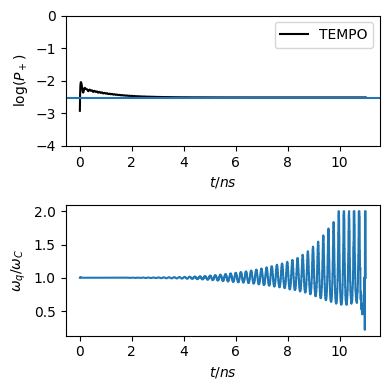

In [102]:


# plt.plot(t_list_half[0:num_steps_half], np.log10((1+np.array(resTDVP))/2), 'k',label='TDVP', linestyle='dotted')
# plt.plot(t_list_half[0:num_steps_half], np.log10((1+np.array(resTDVP))/2), 'k',label='TDVP', linestyle='dashed')
plt.figure(figsize=(4,4))

plt.subplot(211)
plt.plot(t,np.log10(1-p0_0),'k', label = 'TEMPO',linestyle = 'solid')
# plt.plot(t,np.log10(p1_0),'k', label = 'TEMPO',linestyle = 'solid')
# plt.plot(t,np.log10(p2_0),'k', label = 'TEMPO',linestyle = 'solid')
# plt.plot(t,np.log10(p3_0),'k', label = 'TEMPO',linestyle = 'solid')
plt.axhline(y=np.log10((1-p0_pol)))
# plt.axhline(y=np.log10(p1_pol))
# plt.axhline(y=np.log10(p2_pol*2))
# plt.axhline(y=np.log10(p3_pol*3))
plt.legend( prop={'size': 6})
plt.xlabel(r'$t/ns$')
plt.ylabel(r'$\log(P_+)$')
plt.ylim([-4,0])
plt.legend()

plt.subplot(212)
plt.plot(t_list_half[0:num_steps_half],2*h_x_opt/omega_cutoff)
plt.xlabel(r'$t/ns$')
plt.ylabel(r'$\omega_q/\omega_C$')

plt.tight_layout()


plt.show()